<a href="https://colab.research.google.com/github/Mahn17/PLN/blob/main/Notebooks/07-WordEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Word and Document Embeddings</h1>

En esta notebook exploraremos el uso de distintos embeddings para resolver.algunas tareas del NLP.

Los puntos principales de esta notebook son:

In [6]:
import nltk
import pandas as pd
import numpy as np
from nltk import word_tokenize
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
from string import punctuation

nltk.download('punkt_tab')
nltk.download('stopwords')

stopwords = nltk.corpus.stopwords.words('spanish')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
!pip install -qq umap-learn
!pip install gensim

In [10]:
def normalizar_vector(v):
    if np.linalg.norm(v) == 0:
        return v
    else:
        return v / np.linalg.norm(v)

# Exploración word2vec

Usaremos la implementación de gensim: https://radimrehurek.com/gensim/models/word2vec.html.

Tensorflow también tiene una implementación ([tutorial](https://www.tensorflow.org/text/tutorials/word2vec)).

El artículo original: https://arxiv.org/pdf/1301.3781

## Usar un modelo pre-entrenado

### Un modelo de gensim

Gensim tiene varios modelos de word2vec preentrenados:

In [11]:
import gensim.downloader

for x in gensim.downloader.info()['models'].keys():
    print(x)

fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis


Descarguemos alguno de estos modelos.

Tarda alrededor de 20 minutos

In [12]:
import gensim.downloader

pt_w2v_model_kv = gensim.downloader.load('glove-wiki-gigaword-50') # Tarda 1 minuto
# pt_w2v_model_kv = gensim.downloader.load('word2vec-google-news-300')

[==================================================] 100.0% 66.0/66.0MB downloaded


Es un modelo keyedvectors. Hay dos maneras de almacenar y leer un modelo de gensim: el modelo completo y los keyed vectors.

Un modelo completo de Word2Vec en Gensim incluye no solo los vectores aprendidos sino también toda la arquitectura necesaria para seguir entrenando: los pesos de la red neuronal, el vocabulario con sus conteos, el optimizador y demás estructuras internas.

Una vez que el entrenamiento terminó y solo interesa hacer inferencia (buscar palabras similares, calcular distancias, proyectar vectores), podemos extraer únicamente la parte KeyedVectors con model.wv, que es esencialmente un diccionario eficiente de palabra $↔$ vector.

KeyedVectors es más ligero, más rápido de cargar y suficiente para la mayoría de aplicaciones en producción; la desventaja es que ya no se puede continuar entrenando el modelo con nuevos datos, porque se descartan todos los componentes de la red.

In [13]:
type(pt_w2v_model_kv)

gensim.models.keyedvectors.KeyedVectors

Obtengamos los vectores como arreglos de numpy

In [14]:
vectors = pt_w2v_model_kv.vectors
vectors.shape

(400000, 50)

### Un modelo *externo*

Descarguemos un modelo externo y experimentemos con él

In [15]:
!gdown 1k9bBE7ViPU8YxrbHiunns926zx-lip0i

Downloading...
From (original): https://drive.google.com/uc?id=1k9bBE7ViPU8YxrbHiunns926zx-lip0i
From (redirected): https://drive.google.com/uc?id=1k9bBE7ViPU8YxrbHiunns926zx-lip0i&confirm=t&uuid=d83e9265-4c8c-4c3c-a8f5-051ed5dcd924
To: /content/GoogleNews-vectors-negative300.bin.gz
100% 1.65G/1.65G [00:13<00:00, 119MB/s]


Leamos el modelo, **tarda alrededor de 2 minutos**

In [16]:
from gensim.models import KeyedVectors

pretrained_model_path = 'GoogleNews-vectors-negative300.bin.gz'

pt_w2v_model_kv = KeyedVectors.load_word2vec_format(pretrained_model_path, binary=True)

In [ ]:
type(pt_w2v_model_kv)

gensim.models.keyedvectors.KeyedVectors

### Experimentación

Dimensión de los embeddings

In [17]:
pt_w2v_model_kv.vector_size

300

Accedemos al vocabulario

In [18]:
vocabulary = pt_w2v_model_kv.index_to_key
print(f"Tamaño del vocabulario: {len(vocabulary)}")
print(vocabulary[:20])

Tamaño del vocabulario: 3000000
['</s>', 'in', 'for', 'that', 'is', 'on', '##', 'The', 'with', 'said', 'was', 'the', 'at', 'not', 'as', 'it', 'be', 'from', 'by', 'are']


Palabras similares

In [19]:
word = "king"

pt_w2v_model_kv.most_similar(word,topn=15)

[('kings', 0.7138045430183411),
 ('queen', 0.6510956883430481),
 ('monarch', 0.6413194537162781),
 ('crown_prince', 0.6204220056533813),
 ('prince', 0.6159993410110474),
 ('sultan', 0.5864824056625366),
 ('ruler', 0.5797567367553711),
 ('princes', 0.5646552443504333),
 ('Prince_Paras', 0.5432944297790527),
 ('throne', 0.5422105193138123),
 ('Savory_aromas_wafted', 0.5342535972595215),
 ('Simeon_Saxcoburggotski', 0.5291866660118103),
 ('royal', 0.5239794254302979),
 ('kingdom', 0.5210405588150024),
 ('princess', 0.5161998867988586)]

Resolvemos analogías

In [ ]:
pt_w2v_model_kv.most_similar(positive=['woman', 'king'], negative=['man'], topn=5)
# pt_w2v_model_kv.most_similar(positive=['woman', 'actor'], negative=['man'], topn=5)

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581)]

Veamos la similitud coseno entre palabras _similares_ y _no similares_

In [ ]:
# Palabras no similares
word1 = "dream"
word2 = "technology"
similarity1 = pt_w2v_model_kv.similarity(word1, word2)
print(similarity1)

# Palabras relativamente similares
word5 = "computer"
word6 = "pencil"
similarity3 = pt_w2v_model_kv.similarity(word5, word6)
print(similarity3)

# Palabras muy similares
word3 = "boy"
word4 = "girl"
similarity2 = pt_w2v_model_kv.similarity(word3, word4)
print(similarity2)

-0.013827455
0.28710768
0.8543272


## Entrenar un modelo en el corpus

Es importante considerar que el modelo depende mucho de los datos con los que se entrena. Para muchas tareas generales basta con utilizar un modelo preentrenado, pero algunas aplicaciones específicas (por ejemplo, específicas de un dominio especializado) pueden requerir entrenar un modelo en un corpus específico.

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=5, workers=4)

NameError: name 'tokenized_docs' is not defined

Veamos el vocabulario obtenido

In [ ]:
vocabulary = w2v_model.wv.index_to_key
print(f"Tamaño del vocabulario: {len(vocabulary)}")
print(vocabulary[:20])

Los vectores:

In [ ]:
word_vectors = w2v_model.wv.vectors
word_vectors.shape

In [ ]:
# Guardar todo el modelo
w2v_model.save("word2vec.model")

# Guardar sólo los vectores
w2v_model.wv.save("word2vec.wordvectors")

In [ ]:
word = 'amplia'

word_vector = w2v_model.wv[word]

dim = w2v_model.wv.vector_size
print(f"palabra: {word}")
zeros = np.where(word_vector==0)[0].shape[0]
print(f"Número de entradas 0: {zeros}/{dim}={round(100*zeros/dim,2)}%")

Veamos qué pasa con las palabras **OOV**

In [ ]:
w2v_model.wv['holonomia']

# Uso como features

| Modelo   | Granularidad       | Ventaja clave                          |
|----------|--------------------|----------------------------------------|
| Word2Vec | palabra            | rápido, baseline sólido                |
| FastText | subpalabra (n-gramas) | maneja OOV y morfología             |
| GloVe    | palabra            | se entrena sobre co-ocurrencias de todo el corpus a la vez en lugar de ventanas |
| Doc2Vec  | párrafo/doc        | vector para texto completo             |

## Clasificación

In [20]:
stopwords = nltk.corpus.stopwords.words('english')

In [21]:
!gdown 1uKAlVHIUelY1C0DLgc8arLLhoAIwWmdX

Downloading...
From: https://drive.google.com/uc?id=1uKAlVHIUelY1C0DLgc8arLLhoAIwWmdX
To: /content/YoutubeCommentsDataSet.csv
100% 3.49M/3.49M [00:00<00:00, 135MB/s]


In [22]:
import pandas as pd

yt_df = pd.read_csv('YoutubeCommentsDataSet.csv')
yt_df.dropna(inplace=True)
display(yt_df)

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive
...,...,...
18403,i really like the point about engineering tool...,positive
18404,i’ve just started exploring this field and thi...,positive
18405,excelente video con una pregunta filosófica pr...,neutral
18406,hey daniel just discovered your channel a coup...,positive


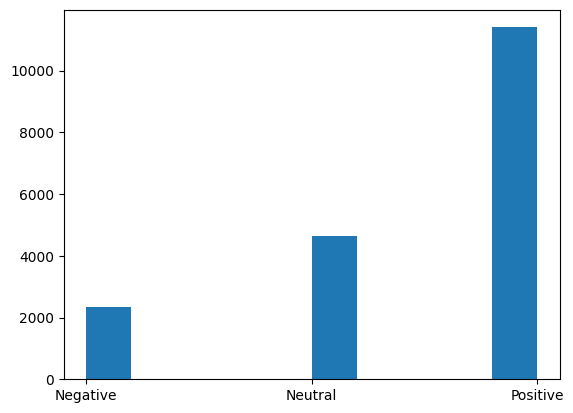

In [23]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

y = LabelEncoder().fit_transform(yt_df['Sentiment'].values)

plt.figure()
plt.hist(y)
plt.xticks([0,1,2],labels=['Negative','Neutral','Positive'])
plt.show()

Dividimos en train/test

In [24]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(yt_df['Comment'].values, y,
                                                            test_size=0.25,
                                                            stratify=y, # IMPORTANTE
                                                            random_state=642)

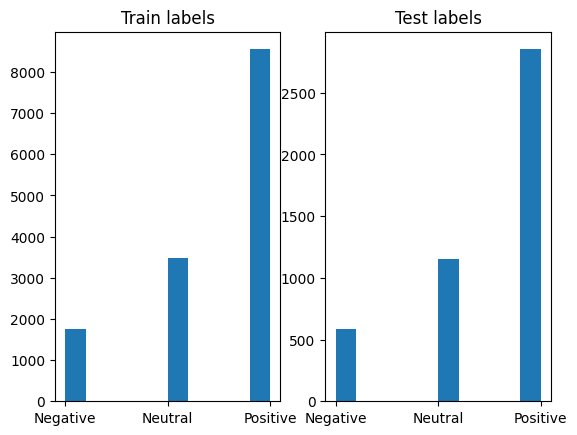

In [25]:
plt.figure()
plt.subplot(1,2,1)
plt.hist(y_train)
plt.title("Train labels")
plt.xticks([0,1,2],labels=['Negative','Neutral','Positive'])
plt.subplot(1,2,2)
plt.hist(y_test)
plt.title("Test labels")
plt.xticks([0,1,2],labels=['Negative','Neutral','Positive'])
plt.show()

In [26]:
import numpy as np

random_idxs = np.random.choice(yt_df.shape[0],5,replace=False)

for j in random_idxs:
    text = yt_df.loc[j,'Comment']
    sentiment = yt_df.loc[j,'Sentiment']
    print(f"{text[:80]}...:\n\t{sentiment}")


protect this man at all cost freeola...:
	neutral
yep watching my hives fade day after day until they completely vanished was such...:
	positive
i love that basically everything has a vegetarian option in india i’m kind of je...:
	positive
i can’t believe kass is pregnant i’m so happy for y’all...:
	positive
this is amazing and really interesting i got so lost because i have insufficient...:
	positive


Preprocesamiento y limpieza

In [27]:
import re

# Tokenización y limpieza para train
X_train_raw = [re.sub(r'\d+', ' ', doc) for doc in X_train_raw]
train_tokenized_docs = [[x for x in word_tokenize(doc) if x not in stopwords and x not in punctuation]
                        for doc in X_train_raw]
print(f"Número de documentos inicial: {len(train_tokenized_docs)}")

# Crear una lista de índices válidos (documentos no vacíos)
train_valid_indices = [i for i, D in enumerate(train_tokenized_docs) if len(D) != 0]

# Filtrar tanto X como y usando los índices válidos
train_tokenized_docs = [train_tokenized_docs[i] for i in train_valid_indices]
y_train = [y_train[i] for i in train_valid_indices]  # Filtrar y_train

print(f"Número de documentos después de filtrar vacíos: {len(train_tokenized_docs)}")
train_docs = [' '.join(doc) for doc in train_tokenized_docs]

# Tokenización y limpieza para test
X_test_raw = [re.sub(r'\d+', ' ', doc) for doc in X_test_raw]
test_tokenized_docs = [[x for x in word_tokenize(doc) if x not in stopwords and x not in punctuation]
                       for doc in X_test_raw]
print(f"Número de documentos inicial: {len(test_tokenized_docs)}")

# Crear una lista de índices válidos (documentos no vacíos)
test_valid_indices = [i for i, D in enumerate(test_tokenized_docs) if len(D) != 0]

# Filtrar tanto X como y usando los índices válidos
test_tokenized_docs = [test_tokenized_docs[i] for i in test_valid_indices]
y_test = [y_test[i] for i in test_valid_indices]  # Filtrar y_test

print(f"Número de documentos después de filtrar vacíos: {len(test_tokenized_docs)}")
test_docs = [' '.join(doc) for doc in test_tokenized_docs]

Número de documentos inicial: 13773
Número de documentos después de filtrar vacíos: 13768
Número de documentos inicial: 4591
Número de documentos después de filtrar vacíos: 4590


In [28]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words=stopwords)
X_train_tfidf = vectorizer.fit_transform(train_docs).toarray()
X_test_tfidf = vectorizer.transform(test_docs).toarray()

### Entrenando nuestro modelo de embeddings

Entrenemos un modelo de word2vec en el corpus IMDB. **Tarda alrededor de 2 minutos**

In [29]:
from gensim.models import Word2Vec

w2v_20ng_model = Word2Vec(sentences=train_tokenized_docs, vector_size=100, window=3, min_count=3, workers=4)

In [30]:
word = 'guys'
w2v_20ng_model.wv[word]

array([-0.19865902,  0.45877972,  0.09867447,  0.10856541,  0.14751123,
       -0.8583678 ,  0.3075221 ,  1.1513572 , -0.31850263, -0.20991732,
       -0.29375395, -1.00482   ,  0.16420586,  0.08963299,  0.08422524,
       -0.7574692 , -0.09414437, -0.67429495, -0.05975269, -1.0804819 ,
        0.2892882 ,  0.225656  ,  0.2574102 ,  0.007557  , -0.08932023,
       -0.21594855, -0.38856038, -0.23720092, -0.41254053,  0.1596984 ,
        0.6770084 , -0.01568486,  0.2878848 , -0.34181204, -0.14772037,
        0.5265605 ,  0.01829839, -0.4168794 , -0.3309822 , -0.8946539 ,
       -0.18726788, -0.6658589 , -0.29984516,  0.06854895,  0.2342658 ,
       -0.20806327, -0.5739315 , -0.11936335,  0.32142594,  0.47130838,
        0.16398539, -0.5042618 , -0.05249209, -0.12734589, -0.27347603,
        0.3668344 ,  0.23887049, -0.15523377, -0.43557796,  0.26422653,
        0.18006338,  0.1438645 ,  0.06613118, -0.15089062, -0.8008582 ,
        0.6766727 ,  0.05420792,  0.5080894 , -0.7392243 ,  0.58

In [31]:
w2v_20ng_model.wv.most_similar(word,topn=10)

[('man', 0.9979491233825684),
 ('hope', 0.9975004196166992),
 ('please', 0.9971782565116882),
 ('channel', 0.9969625473022461),
 ('making', 0.9969120025634766),
 ('us', 0.9968580603599548),
 ('awesome', 0.9961901903152466),
 ('nice', 0.9960513710975647),
 ('hard', 0.9957483410835266),
 ('makes', 0.9950684905052185)]

In [ ]:
text = test_tokenized_docs[0]
print(text)
w2v_20ng_model.wv.get_mean_vector(text)

In [ ]:
train_doc_vectors = np.zeros((len(train_docs), w2v_20ng_model.wv.vector_size))
test_doc_vectors = np.zeros((len(test_docs), w2v_20ng_model.wv.vector_size))

train_zero_vector_num = 0
test_zero_vector_num = 0

for i, doc in enumerate(train_tokenized_docs):
    try:
        train_doc_vectors[i] = w2v_20ng_model.wv.get_mean_vector(doc)
    except:
        train_zero_vector_num += 1

for i, doc in enumerate(test_tokenized_docs):
    try:
        test_doc_vectors[i] = w2v_20ng_model.wv.get_mean_vector(doc)
    except:
        test_zero_vector_num += 1

In [ ]:
print(f"Vectores nulos en el conjunto train: {train_zero_vector_num}")
print(f"Vectores nulos en el conjunto test: {test_zero_vector_num}")

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

models = [SVC(C=10),
          LogisticRegression(C=10),
          MLPClassifier(alpha=0.001,
                        hidden_layer_sizes=(100,)),
          KNeighborsClassifier(metric='cosine',
                               n_neighbors=21
                               )
        ]

model_names = ['SVC','LR','MLP','KNN']
f1_scores_1 = []

for name, model in zip(model_names,models):
    model.fit(train_doc_vectors, y_train)
    train_predictions = model.predict(train_doc_vectors)
    test_predictions = model.predict(test_doc_vectors)
    train_f1 = f1_score(y_train,train_predictions,average='macro')
    test_f1 = f1_score(y_test,test_predictions,average='macro')
    print(f"{name}:\n\tTrain: {round(train_f1,3)}\n\tTest: {round(test_f1,3)}")
    f1_scores_1.append((train_f1,test_f1))

### Usando un modelo pre-entrenado

In [ ]:
!gdown 1k9bBE7ViPU8YxrbHiunns926zx-lip0i

Tarda alrededor de 1 minuto en leer el modelo

In [ ]:
from gensim.models import KeyedVectors

pretrained_model_path = 'GoogleNews-vectors-negative300.bin.gz'

pt_w2v_model = KeyedVectors.load_word2vec_format(pretrained_model_path, binary=True)

In [ ]:
pt_w2v_model.vector_size

In [ ]:
vector_size = pt_w2v_model.vector_size
train_doc_vectors = np.zeros((len(train_docs), vector_size))
test_doc_vectors = np.zeros((len(test_docs), vector_size))

zero_train_vector_idxs = []

train_zero_vector_num = 0
test_zero_vector_num = 0

for i, doc in enumerate(train_tokenized_docs):
    try:
        train_doc_vectors[i] = pt_w2v_model.get_mean_vector(doc)
    except:
        train_zero_vector_num += 1
        zero_train_vector_idxs.append(i)

for i, doc in enumerate(test_tokenized_docs):
    try:
        test_doc_vectors[i] = pt_w2v_model.get_mean_vector(doc)
    except:
        test_zero_vector_num += 1

In [ ]:
print(f"Vectores nulos en el conjunto train: {train_zero_vector_num}")
print(f"Vectores nulos en el conjunto test: {test_zero_vector_num}")

In [ ]:
train_doc_vectors[:4,:5]

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

models = [SVC(),
          LogisticRegression(C=10),
          MLPClassifier(hidden_layer_sizes=(50),
                        alpha=0.001),
          KNeighborsClassifier(metric='cosine',
                               n_neighbors=11)
        ]

model_names = ['SVC','LR','MLP','KNN']
f1_scores_2 = []

print("Pre-trained Word2vec vectors")
for name, model in zip(model_names,models):
    model.fit(train_doc_vectors, y_train)
    train_predictions = model.predict(train_doc_vectors)
    test_predictions = model.predict(test_doc_vectors)
    train_f1 = f1_score(y_train,train_predictions,average='macro')
    test_f1 = f1_score(y_test,test_predictions,average='macro')
    print(f"{name}:\n\tTrain: {round(train_f1,3)}\n\tTest: {round(test_f1,3)}")
    f1_scores_2.append((train_f1,test_f1))

### Baseline

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

models = [SVC(),
          LogisticRegression(),
          MLPClassifier(hidden_layer_sizes=(50)),
          KNeighborsClassifier(metric='cosine')
        ]

model_names = ['SVC','LR','MLP','KNN']
f1_scores_3 = []

print("TF-IDF Baseline")
for name, model in zip(model_names,models):
    model.fit(X_train_tfidf, y_train)
    train_predictions = model.predict(X_train_tfidf)
    test_predictions = model.predict(X_test_tfidf)
    train_f1 = f1_score(y_train,train_predictions,average='macro')
    test_f1 = f1_score(y_test,test_predictions,average='macro')
    print(f"{name}:\n\tTrain: {round(train_f1,3)}\n\tTest: {round(test_f1,3)}")
    f1_scores_3.append((train_f1,test_f1))

### Comparación

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['SVC', 'Log Reg', 'MLP', 'KNN']
approaches = ['W2V Propio', 'W2V Pretrained', 'TF-IDF']
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Verde, Azul, Rojo

# Extraer solo scores de test para cada approach
scores_test = [
    [score[1] for score in f1_scores_1],  # Test scores w2v propio
    [score[1] for score in f1_scores_2],  # Test scores w2v pretrained
    [score[1] for score in f1_scores_3]   # Test scores tfidf
]

# Configurar el gráfico
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

# Crear barras para cada approach
for i, (approach, scores) in enumerate(zip(approaches, scores_test)):
    offset = (i - 1) * width  # Centrar las barras: -width, 0, +width
    bars = ax.bar(x + offset, scores, width, label=approach, color=colors[i], alpha=0.8)

    # Añadir valores en las barras
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Modelos', fontsize=12)
ax.set_ylabel('F1-Score (Macro)', fontsize=12)
ax.set_title('Comparación de estrategias\nF1-Score en Test', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylim([0, 1])
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Topic Modeling

In [ ]:
!gdown 1b0cmrHesxIXzZhxAEqRizdL8zOFXyK9V

In [ ]:
import pandas as pd

df = pd.read_csv('topics_unlabeled.csv')
df

In [ ]:
from nltk.corpus import stopwords
import string
from nltk.tokenize import word_tokenize
import re

STOPWORDS = set(stopwords.words('english'))

def clean_text(text: str) -> list[str]:
    """
    Limpia un documento y retorna lista de tokens lista para W2V.
    Pipeline:
      1. Eliminar HTML tags
      2. Eliminar URLs y emails
      3. Lowercase
      4. Eliminar puntuación y caracteres no-ASCII
      5. Normalizar espacios
      6. Tokenizar
      7. Eliminar stopwords y tokens no alfabéticos
    """
    if not isinstance(text, str):
        return []

    # HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # URLs y emails
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    # Lowercase
    text = text.lower()
    # Puntuación y caracteres no-ASCII
    text = text.encode('ascii', errors='ignore').decode()
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenizar
    tokens = word_tokenize(text)
    # Stopwords y tokens no alfabéticos
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
    return tokens

def clean_dataset(df, output_path: str = None, text_col: str = 'text'):
    """
    Aplica clean_text y agrega columna 'tokens' con la lista de tokens limpios.
    """
    print(f"Shape original: {df.shape}")

    # Eliminar nulos y duplicados
    df = df.dropna(subset=[text_col]).drop_duplicates(subset=[text_col]).reset_index(drop=True)
    print(f"Shape tras drop nulos/duplicados: {df.shape}")

    df['tokens'] = df[text_col].apply(clean_text)

    # Filtrar documentos que quedaron vacíos tras la limpieza
    empty_mask = df['tokens'].apply(len) == 0
    print(f"Documentos vacíos tras limpieza: {empty_mask.sum()} → eliminados")
    df = df[~empty_mask].reset_index(drop=True)

    print(f"Shape final: {df.shape}")

    return df

In [ ]:
df = clean_dataset(df)
df

In [ ]:
tokenized_docs = list(df['tokens'].values)

In [ ]:
from gensim.models import KeyedVectors

pretrained_model_path = 'GoogleNews-vectors-negative300.bin.gz'

pt_w2v_model = KeyedVectors.load_word2vec_format(pretrained_model_path, binary=True)

In [ ]:
import numpy as np

vector_size = pt_w2v_model.vector_size
doc_vectors = np.zeros((len(tokenized_docs), vector_size))

zero_vector_num = 0

for i, doc in enumerate(tokenized_docs):
    try:
        doc_vectors[i] = pt_w2v_model.get_mean_vector(doc)
    except:
        zero_vector_num += 1

print(f"Vectores nulos en el corpus: {zero_vector_num}")

In [ ]:
from sklearn.cluster import KMeans

num_clusters = 8

kmeans = KMeans(n_clusters=num_clusters, random_state=642)
kmeans.fit(doc_vectors)

In [ ]:
from sklearn.metrics import silhouette_score

labels = kmeans.labels_

silhouette_score(doc_vectors, labels)

In [ ]:
df['cluster'] = labels
df

In [ ]:
docs_per_cluster = {j: [] for j in range(num_clusters)}

for cluster in range(num_clusters):
    cluster_docs = df[df['cluster']==cluster]['tokens'].values
    cluster_docs = [" ".join(doc) for doc in cluster_docs]
    docs_per_cluster[cluster] = cluster_docs
    print(f"Cluster{cluster}: {len(cluster_docs)} documentos")

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, num_clusters, figsize=(5*num_clusters, 5))
for cluster, ax in zip(range(num_clusters), axs.flatten()):
    text = " ".join(docs_per_cluster[cluster])

    # Crear la nube de palabras
    wc = WordCloud(
        background_color='white',
        width=800,
        height=400,
        max_words=100,
        colormap='viridis',
        random_state=42
    ).generate(text)

    # Mostrar la nube de palabras en el subplot
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Cluster {cluster}', fontsize=16, fontweight='bold')
    ax.axis('off')

# Ajustar el espaciado entre subplots
plt.tight_layout()
plt.show()

In [ ]:
nums = list(range(2,10))
siluetas = []

for num in nums:
    kmeans = KMeans(n_clusters=num, random_state=642)
    kmeans.fit(doc_vectors)
    silueta = silhouette_score(doc_vectors, kmeans.labels_)
    siluetas.append(silueta)

plt.figure()
plt.plot(nums, siluetas)
plt.xlabel('Número de clusters')
plt.ylabel('Silueta')
plt.title("Silueta vs Número de clusters")
plt.show()

### Graficar documentos y palabras

In [ ]:
#@title Función para graficar en 3d con plotly

import numpy as np
import plotly.graph_objects as go
import plotly.offline as offline

def scatter_plot_3d_plotly(X, y=None, hover_info=None, filename='plot3d.html', fig_title='Plot'):
    """
    Generate an interactive 3D scatter plot using Plotly.
    """

    # Convertir a numpy array y asegurar formato correcto
    X = np.asarray(X, dtype=float)

    assert X.shape[1] == 3, f"X debe tener 3 dimensiones, tiene {X.shape[1]}"
    assert X.shape[0] > 0, "X no puede estar vacío"

    # Extraer coordenadas como listas de Python
    x_coord = X[:, 0].tolist()
    y_coord = X[:, 1].tolist()
    z_coord = X[:, 2].tolist()

    # Validaciones iniciales
    if y is not None:
        y = np.asarray(y)
        assert X.shape[0] == y.shape[0], "X y y deben tener la misma cantidad de puntos"

    if hover_info is not None:
        assert X.shape[0] == len(hover_info), "X y hover_info deben tener la misma cantidad de puntos"
        # Limpiar hover_info: reemplazar None/NaN con string vacío
        try:
            hover_info = [str(text) if text is not None and str(text) != 'nan' else '' for text in hover_info]
            print(f"Hover_info limpio. Primeros 3: {hover_info[:3]}")
        except Exception as e:
            print(f"ERROR en limpieza de hover_info: {e}")
            raise

    # CREAR EL TRACE SEGÚN LOS CASOS
    # Caso 1: Con etiquetas (y no es None)
    if y is not None:
        # Si y es numérico (float/int), usar escala continua de colores
        if np.issubdtype(y.dtype, np.number):
            trace = go.Scatter3d(
                x=x_coord,
                y=y_coord,
                z=z_coord,
                mode='markers',
                marker=dict(
                    size=3,
                    color=y.tolist(),  # Usar los valores de y directamente para el color
                    colorscale='Viridis',
                    cmin=np.min(y),
                    cmax=np.max(y),
                    opacity=0.8,
                    colorbar=dict(title='Valor')
                ),
                text=hover_info if hover_info is not None else [str(val) for val in y],
                hovertemplate='Valor: %{text}<extra></extra>'
            )
        else:
            # Caso: etiquetas categóricas
            unique_labels = np.unique(y)
            n_classes = len(unique_labels)
            label_to_num = {label: i for i, label in enumerate(unique_labels)}
            numeric_labels = [label_to_num[label] for label in y]

            if n_classes <= 10:
                # Colores discretos para pocas clases
                discrete_colors = ['red', 'blue', 'green', 'orange', 'purple',
                                  'brown', 'pink', 'gray', 'olive', 'cyan']
                point_colors = [discrete_colors[i % len(discrete_colors)] for i in numeric_labels]
                trace = go.Scatter3d(
                    x=x_coord,
                    y=y_coord,
                    z=z_coord,
                    mode='markers',
                    marker=dict(size=3, color=point_colors, opacity=0.8),
                    text=hover_info if hover_info is not None else [str(label) for label in y],
                    hovertemplate='Clase: %{text}<extra></extra>'
                )
            else:
                # Muchas clases: usar escala continua
                trace = go.Scatter3d(
                    x=x_coord,
                    y=y_coord,
                    z=z_coord,
                    mode='markers',
                    marker=dict(
                        size=3,
                        color=numeric_labels,
                        colorscale='turbo',
                        cmin=0,
                        cmax=n_classes-1,
                        opacity=0.8
                    ),
                    text=hover_info if hover_info is not None else [str(label) for label in y],
                    hovertemplate='Clase: %{text}<extra></extra>'
                )

    # Caso 2: Sin etiquetas (y es None)
    else:
        # Subcaso: con hover personalizado
        if hover_info is not None:
            try:
                trace = go.Scatter3d(
                    x=x_coord,
                    y=y_coord,
                    z=z_coord,
                    mode='markers',
                    marker=dict(
                        size=3,
                        color='blue',
                        opacity=0.8
                    ),
                    text=hover_info,
                    hovertemplate='%{text}<extra></extra>'
                )
                print("Trace creado exitosamente")
            except Exception as e:
                print(f"ERROR creando trace: {e}")
                print(f"ERROR tipo: {type(e)}")
                import traceback
                traceback.print_exc()
                raise
        else:
            # Subcaso: sin etiquetas ni hover
            trace = go.Scatter3d(
                x=x_coord,
                y=y_coord,
                z=z_coord,
                mode='markers',
                marker=dict(
                    size=3,
                    color='blue',
                    opacity=0.8
                ),
                hoverinfo='none'
            )

    # Crear figura con el trace
    fig = go.Figure(data=[trace])

    # Configurar el layout
    fig.update_layout(
        title=fig_title,
        scene=dict(
            xaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
            ),
            yaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
            ),
            zaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
            ),
            camera=dict(
                up=dict(x=0, y=0, z=1),
                center=dict(x=0, y=0, z=0),
                eye=dict(x=1.2, y=1.2, z=1.2)
            )
        ),
        showlegend=False,
        margin=dict(l=0, r=0, b=0, t=50),
    )

    # Guardar como archivo HTML
    offline.plot(fig, filename=filename, auto_open=False)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(doc_vectors)

In [ ]:
import re

docs_nl = list(df['text'].values)
docs_nl_clean = [re.sub(r'[\n\r]+', ' ', doc) for doc in docs_nl]
hover_preview = [doc[:120] for doc in docs_nl_clean]
hover_preview[:3]

In [ ]:
scatter_plot_3d_plotly(X=X_pca,
                       y=labels,
                       hover_info=hover_preview,
                       filename='topics_unlabeled_pca3d.html',
                       fig_title='Topic Modeling - PCA + KMeans')

Grafiquemos las palabras

In [ ]:
word_vectors = pt_w2v_model.vectors
words = pt_w2v_model.index_to_key

print(word_vectors.shape)
print(len(words))

pca = PCA(n_components=3)
word_vectors_pca3d = pca.fit_transform(word_vectors)

In [ ]:
scatter_plot_3d_plotly(X=word_vectors_pca3d,
                       y=None,
                       hover_info=words,
                       filename='googlenews300_words_pca3d.html',
                       fig_title='GoogleNews300 - PCA')

# Actividad

In [35]:
!gdown 1Kz8MefpMY8tOzYVDnsUTSmPeXeAC7SRP

Downloading...
From: https://drive.google.com/uc?id=1Kz8MefpMY8tOzYVDnsUTSmPeXeAC7SRP
To: /content/evasion_lexica_rahkauz_numbany.csv
100% 2.74M/2.74M [00:00<00:00, 157MB/s]


In [36]:
import pandas as pd

df = pd.read_csv('evasion_lexica_rahkauz_numbany.csv')
df

,texto,vote_average
0,Imprisoned in the 1940s for the double murder ...,8.714
1,"Spanning the years 1945 to 1955 , a chronicle ...",8.686
2,In the continuing saga of the Corleone crime f...,8.572
3,The true story of how businessman Oskar Schind...,8.600
4,The defense and the prosecution have rested an...,8.600
...,...,...
9774,A parolee becomes the target of a massive poli...,5.387
9775,A young woman contracts what she believes to b...,5.386
9776,"Two people , a man and a woman , wake up naked...",5.385
9777,Dawn is an active member of her high - school ...,5.385


Usando un modelo de word2vec, infiere el significado de las palabras:

* rahkauz
* numbany

Imprime algunos documentos que contengan las palabras para que termines de inferir su significado

In [46]:
from gensim.models import Word2Vec
train_tokenized_docs = [[x for x in word_tokenize(doc) if x not in stopwords and x not in punctuation]
                        for doc in df['texto']]

w2v_20ng_model = Word2Vec(sentences=train_tokenized_docs, vector_size=100, window=3, min_count=3, workers=4)

print('Para rahkauz')
word = 'rahkauz'
w2v_20ng_model.wv[word]
w2v_20ng_model.wv.most_similar(word,topn=10)

Para rahkauz


[('love', 0.9969692826271057),
 ('extraordinary', 0.9937860369682312),
 ('Inspired', 0.9914977550506592),
 ('follows', 0.9910668134689331),
 ('two', 0.9906450510025024),
 ('tale', 0.9900825023651123),
 ('friendship', 0.9895176887512207),
 ('Bobby', 0.9894150495529175),
 ('meaning', 0.9893947243690491),
 ('dreams', 0.9887450933456421)]

In [47]:
print('Para numbany')
word2 = 'numbany'
w2v_20ng_model.wv[word2]
w2v_20ng_model.wv.most_similar(word2,topn=10)

Para numbany


[('home', 0.9990026950836182),
 ('inside', 0.9987189173698425),
 ('taking', 0.9986039400100708),
 ('others', 0.998600959777832),
 ('break', 0.9984040260314941),
 ('action', 0.9983729124069214),
 ('far', 0.9983624815940857),
 ('wrong', 0.9983569979667664),
 ('planet', 0.9983524680137634),
 ('deal', 0.9983206391334534)]